## Downloading Script - Run Once for Data download

Used Russell 1000 constituent data from iShares proxy. Yfinance used to pull the rest of the price data for the stocks.

In [35]:
import yfinance as yf
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.colors as mcolors
import plotly.express as px

## Load the datasets and apply a >$30B Market Cap Filter to get the Large Caps
Calculate the performance for the stocks across the two periods/phases:
1. Pre-war - 31st December 2025 to 27th February 2026
2. Post-war - 27th February to 10th April 2026

In [103]:
# 1. Load the clean offline datasets
sp500 = pd.read_csv("sp500_prices_clean.csv", index_col="Date", parse_dates=True)['^GSPC']
df_stocks = pd.read_csv("russell_1000_prices_clean.csv", index_col="Date", parse_dates=True)
df_meta = pd.read_csv("russell_1000_metadata.csv")

# 2. Apply the Strict >$30B Market Cap Filter FIRST
df_large_cap = df_meta[df_meta['Market Cap'] > 30_000_000_000].copy()
eligible_tickers = df_large_cap['Ticker'].tolist()

# Isolate the price data for only these eligible large-cap stocks
valid_tickers = [t for t in eligible_tickers if t in df_stocks.columns]
df_stocks_filtered = df_stocks[valid_tickers]

# 3. Calculate S&P 500 Benchmark Returns
p1_start, p1_end = '2025-12-31', '2026-02-27'
p2_start, p2_end = '2026-03-02', '2026-04-10'

sp500_p1 = (sp500.loc[p1_end] / sp500.loc[p1_start]) - 1
sp500_p2 = (sp500.loc[p2_end] / sp500.loc[p2_start]) - 1

# 4. Iterate and Calculate Stock Performance
results_list = []
for ticker in valid_tickers:
    try:
        prices = df_stocks_filtered[ticker]
        stock_p1 = (prices.loc[p1_end] / prices.loc[p1_start]) - 1
        stock_p2 = (prices.loc[p2_end] / prices.loc[p2_start]) - 1
        
        results_list.append({
            'Ticker': ticker,
            'Sector': df_large_cap.loc[df_large_cap['Ticker'] == ticker, 'Sector'].values[0],
            'Market Cap': df_large_cap.loc[df_large_cap['Ticker'] == ticker, 'Market Cap'].values[0],
            'Phase 1 Return': stock_p1,
            'Phase 2 Return': stock_p2,
            'Outperformed P1': stock_p1 > sp500_p1,
            'Outperformed P2': stock_p2 > sp500_p2
        })
    except KeyError:
        continue

df_results = pd.DataFrame(results_list)

# 5. Extraction of Counts for Visualization
total_russell = len(df_meta)
eligible_count = len(df_results)
p1_winners_count = len(df_results[df_results['Outperformed P1']])
p2_winners_count = len(df_results[df_results['Outperformed P2']])
consistent_count = len(df_results[df_results['Outperformed P1'] & df_results['Outperformed P2']])

# 6. Derived Variables for Flow Logic
excluded_count = total_russell - eligible_count
p1_losers_count = eligible_count - p1_winners_count
p2_only_winners_count = p2_winners_count - consistent_count
p1_winner_p2_loser_count = p1_winners_count - consistent_count
double_loser_count = p1_losers_count - p2_only_winners_count

# 1. Prepare Data
sector_map = dict(zip(df_large_cap['Ticker'], df_large_cap['Sector']))
daily_returns = df_stocks_filtered.pct_change().dropna()
sector_daily = daily_returns.T.groupby(sector_map).median().T
sp500_returns = sp500.pct_change().dropna()

def get_top_performers(df, start, end, top_n=3):
    """Calculates cumulative returns for a period and returns the top N sectors."""
    subset = df.loc[start:end]
    if subset.empty: return []
    cum_ret = (1 + subset.fillna(0)).prod() - 1
    return cum_ret.sort_values(ascending=False).head(top_n).index.tolist()

# Automatically identify the stars of each phase
top3_p1 = get_top_performers(sector_daily, p1_start, p1_end, 3)
top3_p2 = get_top_performers(sector_daily, p2_start, p2_end, 3)
combined_highlights = list(set(top3_p1 + top3_p2))

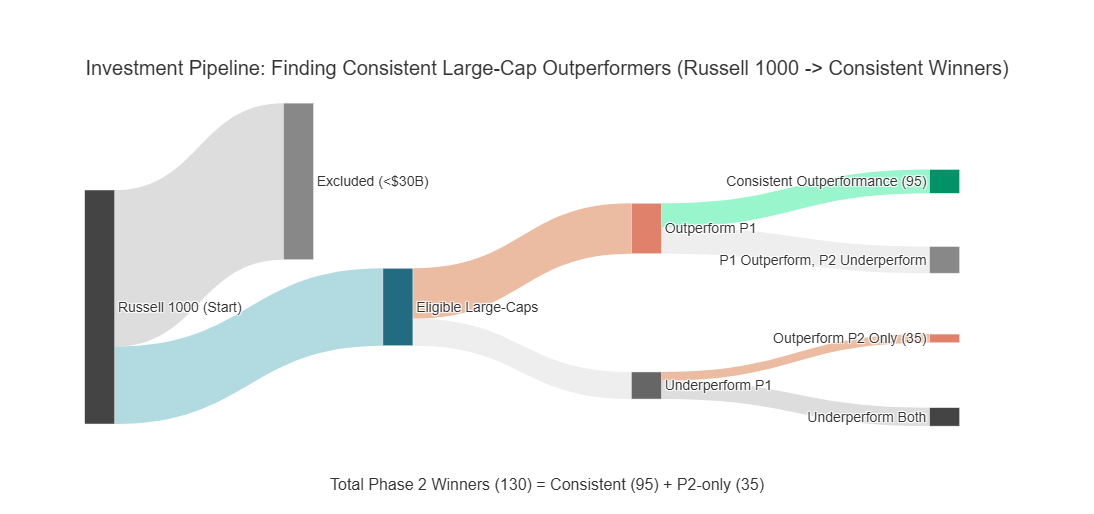

In [97]:
import plotly.graph_objects as go
import pandas as pd

# 2. Define node labels and indices (the order determines positions)
# Indices: 0-Start, 1-Excluded, 2-Eligible, 3-Won P1, 4-Lost P1, 
# 5-Consistent P1/P2, 6-P1 Winner/P2 Loser, 7-P2 Only Winner, 8-P1 Loser/P2 Loser
node_labels = [
    "Russell 1000 (Start)", 
    "Excluded (<$30B)", 
    "Eligible Large-Caps", 
    "Outperform P1", 
    "Underperform P1",
    "Consistent Outperformance (95)", # Highlight this node
    "P1 Outperform, P2 Underperform",
    "Outperform P2 Only (35)", # This preserves your total of 130 (95 + 35)
    "Underperform Both"
]

# (Simplified color definition for clarity, real chart uses gradients)
node_colors = ["#444", "#888", "#226B80", "#E0816C", "#666", "#019267", "#888", "#E0816C", "#444"]

# 3. Create the Sankey Diagram
fig = go.Figure(go.Sankey(
    orientation = "h", # Keep horizontal, it flows better
    node = dict(
        pad = 20, # More space between nodes
        thickness = 30,
        line = dict(color = "#eee", width = 0.5),
        label = node_labels,
        color = node_colors,
        # Positions: range [0,1] for x,y. You might need to refine these based on exact counts.
        x = [0.05, 0.25, 0.35, 0.60, 0.60, 0.90, 0.90, 0.90, 0.90],
        y = [0.5, 0.1, 0.5, 0.25, 0.75, 0.10, 0.35, 0.60, 0.85],
    ),
    link = dict(
        source = [0, 0, 2, 2, 3, 3, 4, 4], # Indices of node_labels list
        target = [1, 2, 3, 4, 5, 6, 7, 8],
        value = [excluded_count, eligible_count, p1_winners_count, p1_losers_count, consistent_count, 
                 p1_winners_count - consistent_count, p2_only_winners_count, p1_losers_count - p2_only_winners_count],
        color = ["#ddd", "#b1dbe1", "#ecbca2", "#eee", "#99f5cb", "#eee", "#ecbca2", "#ddd"], # Match source node colors
    )
))

# 4. Format the layout
fig.update_layout(
    title = dict(
        text = "Investment Pipeline: Finding Consistent Large-Cap Outperformers (Russell 1000 -> Consistent Winners)",
        font_size = 20,
        x=0.5
    ),
    font = dict(family = "Arial", size = 14, color = "#333"),
    # *** Resizing: Make it tall and spacious ***
    margin=dict(t=150, b=50, l=50, r=50),
    height = 500, 
    width = 1100,
    template = "plotly_white",
    hovermode = 'x'
)

# 5. Add callouts to highlight the recovered 130 number

fig.add_annotation(
    x=0.5, y=-0.10, text=f"Total Phase 2 Winners (130) = Consistent (95) + P2-only (35)",
    showarrow=False, font=dict(color="#333", size=16),
)

fig.show()

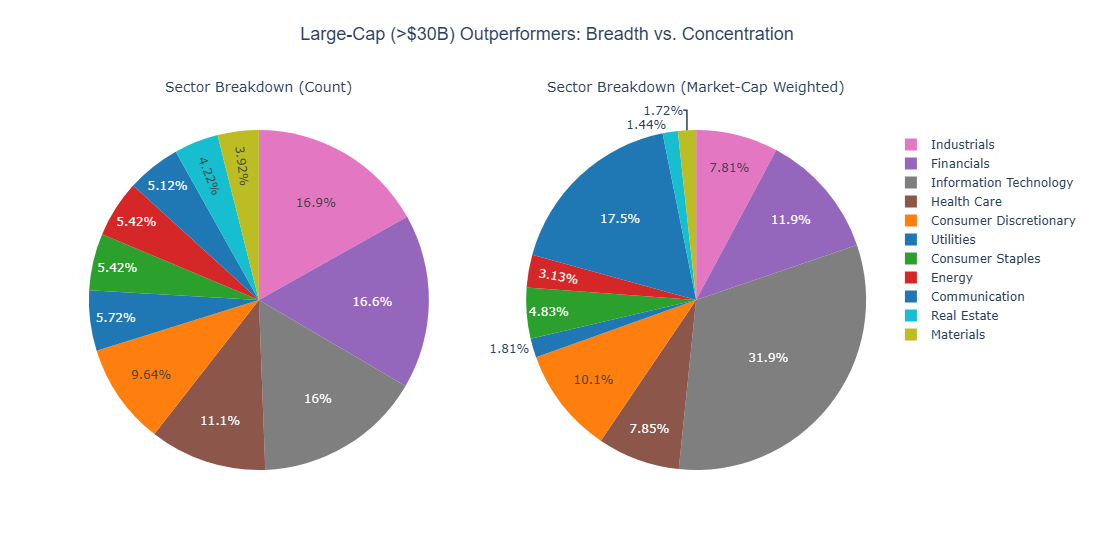

In [98]:
# 1. Calculate aggregates
sector_counts = df_results['Sector'].value_counts().reset_index()
sector_counts.columns = ['Sector', 'Count']

# Sort by Count (Descending) to establish the master order
sector_counts = sector_counts.sort_values(by='Count', ascending=False)
ordered_sectors = sector_counts['Sector'].tolist()

# 2. Calculate Market Cap Weights and force it into the exact same order
sector_weights = df_results.groupby('Sector')['Market Cap'].sum().reset_index()
sector_weights.columns = ['Sector', 'Total Market Cap']
# Reindex to match the Count order
sector_weights = sector_weights.set_index('Sector').reindex(ordered_sectors).reset_index()

# 2. Define a consistent master color palette for ALL possible sectors

all_sectors = sector_daily.columns
colors = list(mcolors.TABLEAU_COLORS.values()) 
master_palette = {sector: colors[i % len(colors)] for i, sector in enumerate(all_sectors)}

# 3. Apply the consistent master palette based on the ordered list
colors_mapped = [master_palette.get(sec, '#333333') for sec in ordered_sectors]

# Create side-by-side pie charts
fig = make_subplots(rows=1, cols=2, specs=[[{'type': 'domain'}, {'type': 'domain'}]],
                    subplot_titles=['Sector Breakdown (Count)', 'Sector Breakdown (Market-Cap Weighted)'])

# Pie 1: Count (Sorted largest to smallest)
fig.add_trace(go.Pie(labels=sector_counts['Sector'], values=sector_counts['Count'], 
                     marker=dict(colors=colors_mapped), name='Count',
                     sort=False, # Disable Plotly's auto-sort so it uses our dataframe order
                     direction='clockwise', # Start at 12 o'clock and go clockwise
                     hovertemplate="<b>%{label}</b><br>Count: %{value}<br>Share: %{percent}<extra></extra>"),
              1, 1)

# Pie 2: Market Cap Weighted (Forced into the same slice order as Pie 1)
fig.add_trace(go.Pie(labels=sector_weights['Sector'], values=sector_weights['Total Market Cap'], 
                     marker=dict(colors=colors_mapped), name='Notional',
                     sort=False, # Must be False to maintain the parallel order
                     direction='clockwise',
                     hovertemplate="<b>%{label}</b><br>Market Cap: $%{value:,.0f}<br>Share: %{percent}<extra></extra>"),
              1, 2)

fig.update_layout(
    title={
        'text': "Large-Cap (>$30B) Outperformers: Breadth vs. Concentration",
        'y': 0.95,               # Vertical position (0 to 1)
        'x': 0.5,                # Horizontal center
        'xanchor': 'center',     # Anchor the text at the center
        'yanchor': 'top',
        'font': dict(size=18, family="Arial, bold")
    },
    margin=dict(t=130),          # Increase top margin to give titles room to breathe
    height=550                   # Slightly taller to accommodate the gaps
)

# Move subplot titles (Subtitles) slightly higher
# This loop looks for the annotations created by 'subplot_titles'
for annotation in fig.layout.annotations:
    annotation.y += 0.10         # Increase this value to move subtitles further up
    annotation.font.size = 14    # Optional: adjust subtitle font size if needed

fig.show()

## Aggregating the Sectorial Performance

We aggregate the Sectorial Performance, looking at median, mean and max just to see the 

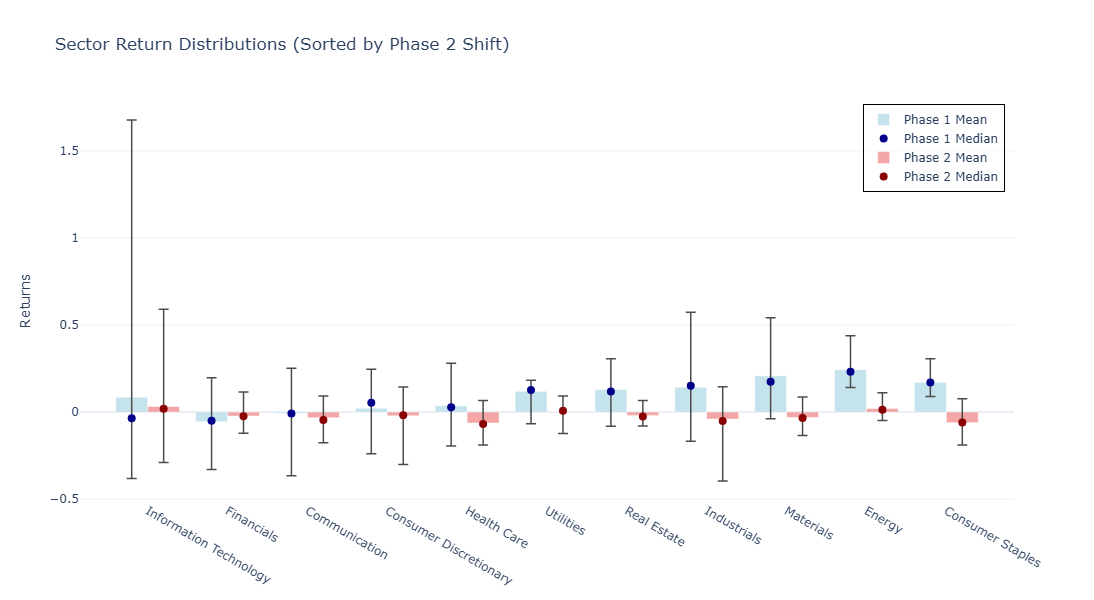

In [99]:
# 1. Calculate metrics and immediately FLATTEN the MultiIndex columns
agg_metrics = df_results.groupby('Sector')[['Phase 1 Return', 'Phase 2 Return']].agg(['mean', 'median', 'min', 'max'])

# This line joins the tuples (e.g., 'Phase 1 Return', 'mean') into strings ('Phase 1 Return_mean')
agg_metrics.columns = ['_'.join(col).strip() for col in agg_metrics.columns.values]

# 2. Calculate the 'Shift' (Delta) and Sort the data
agg_metrics['Median_Delta'] = agg_metrics['Phase 2 Return_median'] - agg_metrics['Phase 1 Return_median']
agg_metrics = agg_metrics.sort_values('Median_Delta', ascending=False)

# Extract specific arrays for plotting
sectors = agg_metrics.index
x_base = np.arange(len(sectors)) 
offset = 0.2

fig = go.Figure()

# --- PHASE 1 TRACES (Shifted Left) ---
fig.add_trace(go.Bar(
    name='Phase 1 Mean', x=x_base - offset, y=agg_metrics['Phase 1 Return_mean'],
    marker_color='lightblue', opacity=0.7, width=0.4, textposition='none',
    error_y=dict(
        type='data', symmetric=False,
        array=agg_metrics['Phase 1 Return_max'] - agg_metrics['Phase 1 Return_mean'],
        arrayminus=agg_metrics['Phase 1 Return_mean'] - agg_metrics['Phase 1 Return_min'],
        color='black', thickness=1.5, width=5
    ),
    customdata=agg_metrics[['Phase 1 Return_median', 'Phase 1 Return_min', 'Phase 1 Return_max', 'Median_Delta']],
    hovertemplate="<b>%{text} (Phase 1)</b><br>Mean: %{y:.2%}<br>Median: %{customdata[0]:.2%}<br>Min: %{customdata[1]:.2%}<br>Max: %{customdata[2]:.2%}<br>Shift into Phase 2: %{customdata[3]:.2%}<extra></extra>",
    text=sectors # Pass the text names for the hover tooltip
))

# Explicitly place Median Dots on the exact same shifted X-axis
fig.add_trace(go.Scatter(
    name='Phase 1 Median', x=x_base - offset, y=agg_metrics['Phase 1 Return_median'],
    mode='markers', marker=dict(color='darkblue', size=8),
    hoverinfo='skip' # Prevent double hover tooltips
))

# --- PHASE 2 TRACES (Shifted Right) ---
fig.add_trace(go.Bar(
    name='Phase 2 Mean', x=x_base + offset, y=agg_metrics['Phase 2 Return_mean'],
    marker_color='lightcoral', opacity=0.7, width=0.4, textposition='none',
    error_y=dict(
        type='data', symmetric=False,
        array=agg_metrics['Phase 2 Return_max'] - agg_metrics['Phase 2 Return_mean'],
        arrayminus=agg_metrics['Phase 2 Return_mean'] - agg_metrics['Phase 2 Return_min'],
        color='black', thickness=1.5, width=5
    ),
    customdata=agg_metrics[['Phase 2 Return_median', 'Phase 2 Return_min', 'Phase 2 Return_max', 'Median_Delta']],
    hovertemplate="<b>%{text} (Phase 2)</b><br>Mean: %{y:.2%}<br>Median: %{customdata[0]:.2%}<br>Min: %{customdata[1]:.2%}<br>Max: %{customdata[2]:.2%}<extra></extra>",
    text=sectors
))

fig.add_trace(go.Scatter(
    name='Phase 2 Median', x=x_base + offset, y=agg_metrics['Phase 2 Return_median'],
    mode='markers', marker=dict(color='darkred', size=8),
    hoverinfo='skip'
))

# Overwrite the numeric X-axis with the actual Sector names
fig.update_layout(
    title='Sector Return Distributions (Sorted by Phase 2 Shift)',
    yaxis_title='Returns',
    xaxis=dict(tickmode='array', tickvals=x_base, ticktext=sectors),
    barmode='overlay', # Change to overlay since we manually offset the bars
    height=600, 
    width=1090, # Increased width to create more space between sectors
    template='plotly_white',
    hovermode='x unified',

    legend=dict(
        yanchor="top",
        y=0.99,           # 1.0 is the very top
        xanchor="right",
        x=0.99,           # 1.0 is the very far right
        bgcolor="rgba(255, 255, 255, 0.5)", # Semi-transparent white
        bordercolor="Black",
        borderwidth=1
    )
)
fig.show()

## Plotting Sectorial Data for each Period

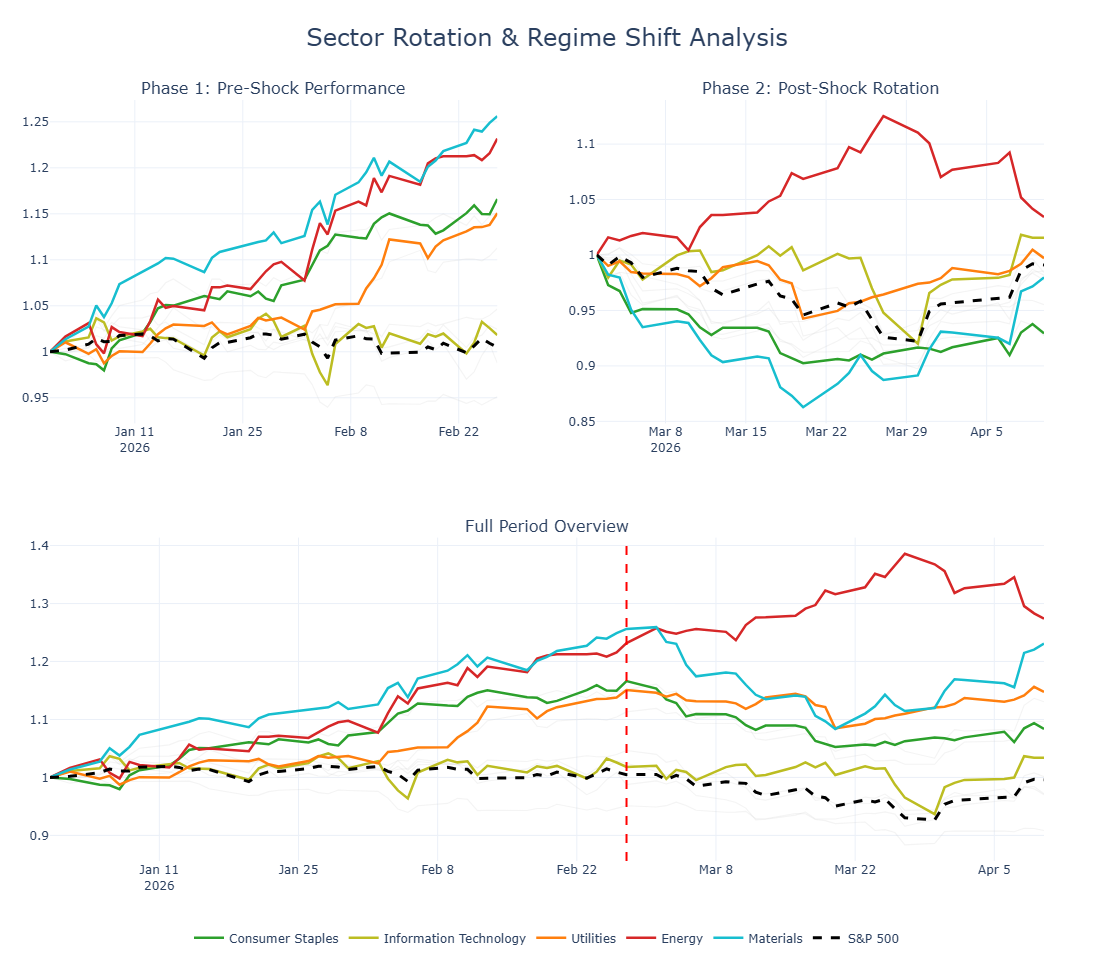

In [101]:
# Color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#bcbd22', '#17becf']
master_palette = {s: colors[i % len(colors)] for i, s in enumerate(sorted(sector_daily.columns))}

# 3. VISUALIZATION SETUP
fig = make_subplots(
    rows=2, cols=2,
    vertical_spacing=0.15, # Reduced gap between top and bottom
    specs=[[{"type": "xy"}, {"type": "xy"}],
           [{"type": "xy", "colspan": 2}, None]],
    subplot_titles=("Phase 1: Pre-Shock Performance", "Phase 2: Post-Shock Rotation", "Full Period Overview")
)

def add_subplot_traces(fig, start_date, end_date, highlight_sectors, row, col, add_vline=False):
    s_returns = sector_daily.loc[start_date:end_date]
    sp_returns = sp500_returns.loc[start_date:end_date]
    
    # FIX 1: Prevent double-counting the "Shock Day". 
    # If the slice starts on Feb 27 (Phase 2), we only want returns AFTER Feb 27.
    if start_date == '2026-02-27':
        s_returns = s_returns.iloc[1:]
        sp_returns = sp_returns.iloc[1:]
        
    # FIX 2: Calculate Compounded Growth WITHOUT dividing by iloc[0]
    s_indexed = (1 + s_returns.fillna(0)).cumprod()
    sp_indexed = (1 + sp_returns.fillna(0)).cumprod()
    
    # FIX 3: Manually prepend a "1.0" at the start date so the line visually anchors properly
    start_dt = pd.to_datetime(start_date)
    s_indexed.loc[start_dt] = 1.0
    sp_indexed.loc[start_dt] = 1.0
    
    # Sort the index so the 1.0 sits at the very beginning of the timeline
    s_indexed = s_indexed.sort_index()
    sp_indexed = sp_indexed.sort_index()
    
    # --- STEP 1: THE GHOST LAYER (Background) ---
    for sector in s_indexed.columns:
        fig.add_trace(go.Scatter(
            x=s_indexed.index, y=s_indexed[sector], mode='lines', 
            line=dict(color='lightgrey', width=1.1), opacity=0.25, 
            name=f"{sector}_bg", showlegend=False, hoverinfo='skip'
        ), row=row, col=col)
            
    # --- STEP 2: THE HIGHLIGHT LAYER (Foreground) ---
    for sector in highlight_sectors:
        fig.add_trace(go.Scatter(
            x=s_indexed.index, y=s_indexed[sector], mode='lines', 
            line=dict(color=master_palette.get(sector, 'black'), width=2.5), 
            name=sector, legendgroup=sector, 
            showlegend=(row==2 and col==1), 
            hovertemplate="<b>%{fullData.name}</b>: %{y:.3f}<extra></extra>"
        ), row=row, col=col) 

    # S&P 500 Benchmark
    fig.add_trace(go.Scatter(
        x=sp_indexed.index, y=sp_indexed, mode='lines', 
        line=dict(color='black', width=3, dash='dash'), 
        name='S&P 500', legendgroup='S&P 500', 
        showlegend=(row==2 and col==1),
        hovertemplate="<b>%{fullData.name}</b>: %{y:.3f}<extra></extra>"
    ), row=row, col=col)
                                 
    if add_vline:
        fig.add_vline(x='2026-02-27', line_width=2, line_dash="dash", line_color="red", row=row, col=col)

# 4. RENDER TRACES
add_subplot_traces(fig, p1_start, p1_end, combined_highlights, 1, 1)
add_subplot_traces(fig, p2_start, p2_end, combined_highlights, 1, 2)
add_subplot_traces(fig, p1_start, p2_end, combined_highlights, 2, 1, add_vline=True)

# 5. FINAL LAYOUT & BEHAVIOR
fig.update_layout(
    height=950, 
    width=1100,
    template='plotly_white', 
    
    # Centralized Title
    title={
        'text': "Sector Rotation & Regime Shift Analysis",
        'y': 0.97,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 24}
    },
    
    # Legend Behavior: Toggle Others (Focus Mode)
    legend=dict(
        orientation="h", 
        yanchor="bottom", y=-0.12, 
        xanchor="center", x=0.5,
        itemclick="toggleothers",   # Single click: Isolate this sector
        itemdoubleclick="toggle",   # Double click: Show all highlights again
        font={'size': 12}
    ),
    
    margin=dict(t=100, b=100, l=50, r=50),
    hovermode='x unified'
)

fig.show()

In [88]:
def calculate_effective_levers(returns_df):
    # Calculate the variance contribution of each sector
    variances = returns_df.var()
    total_variance = variances.sum()
    
    # Transform into probability-like weights (must sum to 1)
    weights = variances / total_variance
    
    # Calculate Shannon Entropy: H = -sum(p * ln(p))
    # Add a tiny epsilon to avoid log(0)
    entropy = -np.sum(weights * np.log(weights + 1e-10))
    
    # Second term: Number of effective levers
    n_effective = np.exp(entropy)
    return entropy, n_effective

# Slice daily returns for both phases
p1_sector_returns = sector_daily.loc['2025-12-31':'2026-02-27']
p2_sector_returns = sector_daily.loc['2026-02-27':'2026-04-10']

h_p1, n_p1 = calculate_effective_levers(p1_sector_returns)
h_p2, n_p2 = calculate_effective_levers(p2_sector_returns)

print(f"Phase 1 - Shannon Entropy: {h_p1:.3f} | Effective Levers: {n_p1:.2f}")
print(f"Phase 2 - Shannon Entropy: {h_p2:.3f} | Effective Levers: {n_p2:.2f}")
print(f"Change in Effective Diversification: {n_p2 - n_p1:.2f} levers")

Phase 1 - Shannon Entropy: 2.286 | Effective Levers: 9.84
Phase 2 - Shannon Entropy: 2.288 | Effective Levers: 9.86
Change in Effective Diversification: 0.02 levers


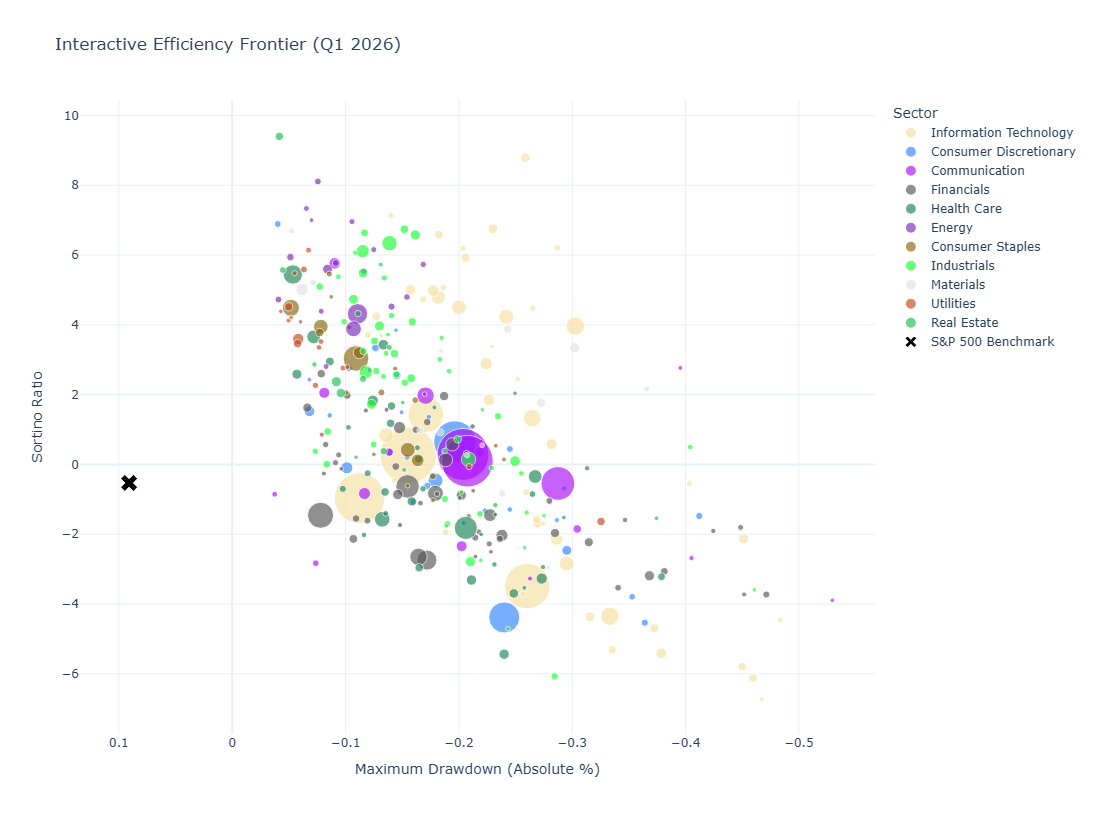

In [89]:
# 1. Calculate S&P 500 Benchmark Metrics
risk_free_rate = 0.045 / 252
daily_ret_sp = sp500.pct_change().dropna()

# Benchmark Sharpe
excess_sp = daily_ret_sp - risk_free_rate
sp500_sharpe = np.sqrt(252) * (excess_sp.mean() / excess_sp.std())

# Benchmark Sortino
downside_sp = daily_ret_sp[daily_ret_sp < 0].std() * np.sqrt(252)
sp500_sortino = ((daily_ret_sp.mean() * 252) - 0.045) / downside_sp if downside_sp != 0 else np.nan

# Benchmark Max Drawdown
cum_ret_sp = (1 + daily_ret_sp).cumprod()
sp500_max_dd = ((cum_ret_sp - cum_ret_sp.cummax()) / cum_ret_sp.cummax()).min()

# 1. Create a dictionary to map Tickers to Full Company Names
# Assuming df_iwb is your original loaded IWB_holdings.csv
name_map = dict(zip(df_iwb['Ticker'], df_iwb['Name']))

risk_free_rate = 0.045 / 252 
metrics_list = []

for ticker in valid_tickers: 
    prices = df_stocks_filtered[ticker]
    daily_ret = prices.pct_change().dropna()
    
    # Sharpe
    excess = daily_ret - risk_free_rate
    sharpe = np.sqrt(252) * (excess.mean() / excess.std())
    
    # Sortino
    downside_std = (daily_ret[daily_ret < 0]).std() * np.sqrt(252)
    sortino = ((daily_ret.mean() * 252) - 0.045) / downside_std if downside_std != 0 else np.nan
    
    # Max Drawdown
    cum_ret = (1 + daily_ret).cumprod()
    max_dd = ((cum_ret - cum_ret.cummax()) / cum_ret.cummax()).min()
    
    # Extract Metadata
    market_cap = df_large_cap.loc[df_large_cap['Ticker'] == ticker, 'Market Cap'].values[0]
    sector = df_large_cap.loc[df_large_cap['Ticker'] == ticker, 'Sector'].values[0] 
    
    # Get the full company name (default to the ticker if not found)
    company_name = name_map.get(ticker, ticker)
    
    metrics_list.append({
        'Ticker': ticker,
        'Company Name': company_name, # Added Company Name
        'Sector': sector,
        'Sharpe': sharpe,
        'Sortino Ratio': sortino,
        'Max Drawdown': max_dd,
        'Market Cap': market_cap
    })

df_metrics = pd.DataFrame(metrics_list).dropna()

# Function to format Market Cap to 3 sig figs with suffixes
def format_market_cap(val):
    if val >= 1e12: return f"${val/1e12:.3g}T"
    if val >= 1e9:  return f"${val/1e9:.3g}B"
    if val >= 1e6:  return f"${val/1e6:.3g}M"
    return f"${val:.3g}"

# Apply formatting to the dataframe
df_metrics['Market Cap of Stock'] = df_metrics['Market Cap'].apply(format_market_cap)

colors = px.colors.qualitative.Alphabet
# 2. Map the consistent colors (Ensure master_palette exists)

master_palette = {s: colors[i % len(colors)] for i, s in enumerate(sorted(sector_daily.columns))}
color_discrete_map = {sec: master_palette[sec] for sec in df_metrics['Sector'].unique()}

# 3. Generate the Interactive Plotly Chart
fig = px.scatter(
    df_metrics,
    x="Max Drawdown",
    y="Sortino Ratio",
    size="Market Cap",
    color="Sector", 
    color_discrete_map=color_discrete_map, 
    opacity=0.65, # Makes overlapping bubbles look like "blended" colors
    hover_name="Company Name", # Set hover title to the full name
    hover_data={
        "Ticker": True, 
        "Market Cap of Stock": True,
        "Sharpe": ":.3f",          # Rounds ratios to 3 decimal places
        "Sortino Ratio": ":.3f", 
        "Max Drawdown": ":.3f",
        "Market Cap": False       # Hide raw number
         # Show formatted string
    },
    title="Interactive Efficiency Frontier (Q1 2026)",
    labels={"Max Drawdown": "Maximum Drawdown (Absolute %)", "Sortino Ratio": "Sortino Ratio"},
    size_max=40,
    template="plotly_white",
    height=800, 
    width=1090  
)

# Reverse the X-axis
fig.update_xaxes(autorange="reversed")

# Add the S&P 500 Baseline 
fig.add_scatter(
    x=[abs(sp500_max_dd)], 
    y=[sp500_sortino], 
    mode='markers', 
    marker=dict(size=15, color='black', symbol='x'), 
    name='S&P 500 Benchmark'
)

fig.update_traces(marker=dict(line=dict(width=1, color='white')))

fig.show()

In [102]:
# 1. Calculate the compounded returns for the Benchmark (S&P 500)
sp500_p1 = (1 + sp500_returns.loc[p1_start:p1_end]).prod() - 1
sp500_p2 = (1 + sp500_returns.loc[p2_start:p2_end]).prod() - 1

# 2. Calculate the compounded returns for each Sector
p1_sector_returns = (1 + sector_daily.loc[p1_start:p1_end]).prod() - 1
p2_sector_returns = (1 + sector_daily.loc[p2_start:p2_end]).prod() - 1

# 3. Create the Base DataFrame
sector_phase_returns = pd.DataFrame({
    'Phase 1 Return': p1_sector_returns,
    'Phase 2 Return': p2_sector_returns
})

# --- METHOD 1: Active Return Shift ---
sector_phase_returns['P1 Active Return'] = sector_phase_returns['Phase 1 Return'] - sp500_p1
sector_phase_returns['P2 Active Return'] = sector_phase_returns['Phase 2 Return'] - sp500_p2
sector_phase_returns['Active Return Delta'] = sector_phase_returns['P2 Active Return'] - sector_phase_returns['P1 Active Return']

# --- METHOD 2: Cross-Sectional Z-Scoring ---
p1_mean = sector_phase_returns['Phase 1 Return'].mean()
p1_std = sector_phase_returns['Phase 1 Return'].std()

p2_mean = sector_phase_returns['Phase 2 Return'].mean()
p2_std = sector_phase_returns['Phase 2 Return'].std()

sector_phase_returns['P1 Z-Score'] = (sector_phase_returns['Phase 1 Return'] - p1_mean) / p1_std
sector_phase_returns['P2 Z-Score'] = (sector_phase_returns['Phase 2 Return'] - p2_mean) / p2_std
sector_phase_returns['Z-Score Shift'] = sector_phase_returns['P2 Z-Score'] - sector_phase_returns['P1 Z-Score']

# Sort by the new Z-Score Shift to see who actually gained relative dominance
advanced_shift_df = sector_phase_returns.sort_values(by='Z-Score Shift', ascending=False)

print("--- ADVANCED SECTOR MOMENTUM SHIFT ---")
display(advanced_shift_df[['Phase 1 Return', 'Phase 2 Return', 'Active Return Delta', 'P1 Z-Score', 'P2 Z-Score', 'Z-Score Shift']].style.format({
    'Phase 1 Return': '{:.2%}',
    'Phase 2 Return': '{:.2%}',
    'Active Return Delta': '{:.2%}',
    'P1 Z-Score': '{:.2f}σ',
    'P2 Z-Score': '{:.2f}σ',
    'Z-Score Shift': '{:.2f}σ'
}).background_gradient(subset=['Z-Score Shift','Active Return Delta'], cmap='RdYlGn'))

--- ADVANCED SECTOR MOMENTUM SHIFT ---


,Phase 1 Return,Phase 2 Return,Active Return Delta,P1 Z-Score,P2 Z-Score,Z-Score Shift
Information Technology,1.81%,1.55%,1.13%,-0.81σ,1.13σ,1.94σ
Financials,-1.23%,-1.59%,1.04%,-1.11σ,0.16σ,1.28σ
Communication,-4.89%,-4.48%,1.80%,-1.48σ,-0.73σ,0.75σ
Consumer Discretionary,2.46%,-2.27%,-3.35%,-0.75σ,-0.05σ,0.70σ
Energy,23.17%,3.42%,-18.36%,1.31σ,1.71σ,0.40σ
Real Estate,11.31%,-1.45%,-11.37%,0.13σ,0.21σ,0.07σ
Utilities,15.07%,-0.28%,-13.97%,0.51σ,0.57σ,0.06σ
Industrials,15.15%,-1.82%,-15.58%,0.51σ,0.09σ,-0.42σ
Health Care,4.65%,-7.29%,-10.55%,-0.53σ,-1.59σ,-1.07σ
Materials,25.62%,-2.02%,-26.24%,1.55σ,0.03σ,-1.52σ


In [104]:
advanced_shift_df

,Phase 1 Return,Phase 2 Return,P1 Active Return,P2 Active Return,Active Return Delta,P1 Z-Score,P2 Z-Score,Z-Score Shift
Information Technology,0.018137,0.015528,0.013261,0.024539,0.011278,-0.809929,1.131258,1.941187
Financials,-0.012341,-0.015862,-0.017217,-0.006851,0.010366,-1.112392,0.163532,1.275925
Communication,-0.048931,-0.044771,-0.053807,-0.035759,0.018047,-1.475500,-0.727693,0.747807
Consumer Discretionary,0.024643,-0.022708,0.019766,-0.013696,-0.033462,-0.745373,-0.047497,0.697876
Energy,0.231689,0.034249,0.226812,0.043260,-0.183552,1.309310,1.708407,0.399097
Real Estate,0.113082,-0.014471,0.108206,-0.005459,-0.113665,0.132286,0.206442,0.074156
Utilities,0.150709,-0.002839,0.145833,0.006173,-0.139660,0.505684,0.565044,0.059360
Industrials,0.151453,-0.018233,0.146577,-0.009221,-0.155798,0.513068,0.090465,-0.422603
Health Care,0.046494,-0.072865,0.041618,-0.063853,-0.105471,-0.528527,-1.593804,-1.065277
Materials,0.256164,-0.020165,0.251288,-0.011154,-0.262441,1.552197,0.030877,-1.521320


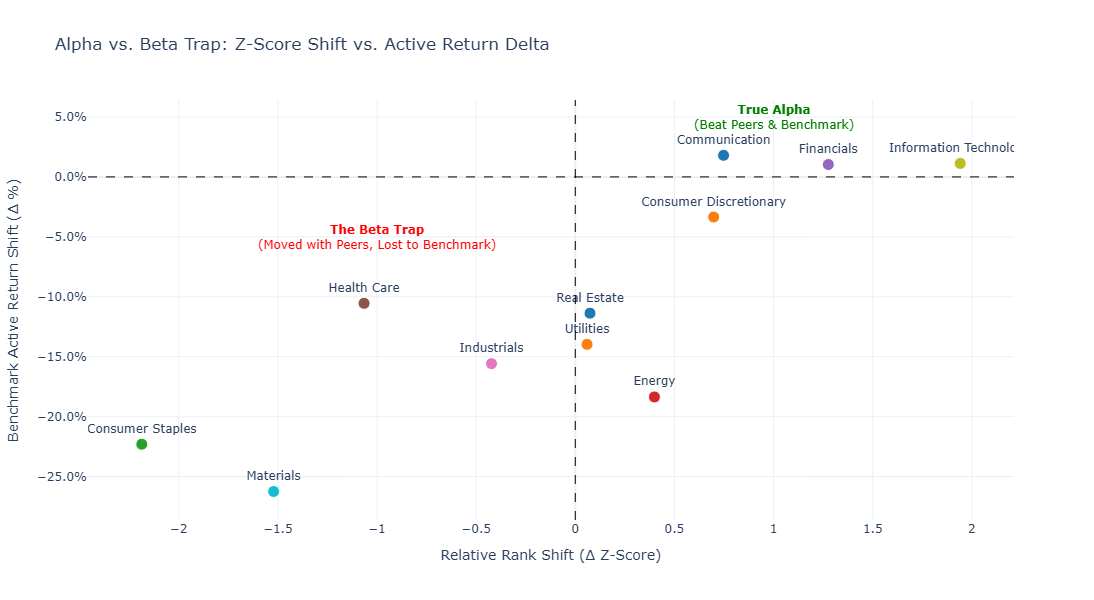

In [105]:
import plotly.express as px

# Assuming 'advanced_shift_df' contains your Z-Score Shift and Active Return Delta columns
fig_trap = px.scatter(
    advanced_shift_df.rename_axis("Sector").reset_index(),    
    x="Z-Score Shift", 
    y="Active Return Delta", 
    color="Sector",
    color_discrete_map=master_palette,
    text="Sector", # Puts the sector name directly on the chart
    title="Alpha vs. Beta Trap: Z-Score Shift vs. Active Return Delta",
    labels={
        "Z-Score Shift": "Relative Rank Shift (Δ Z-Score)",
        "Active Return Delta": "Benchmark Active Return Shift (Δ %)"
    },
    template="plotly_white",
    height=600
)

# Format the Y-axis as a percentage
fig_trap.update_yaxes(tickformat=".1%")

# Add quadrant lines
fig_trap.add_hline(y=0, line_dash="dash", line_color="black", line_width=1)
fig_trap.add_vline(x=0, line_dash="dash", line_color="black", line_width=1)

# Position the text so it doesn't overlap the bubbles
fig_trap.update_traces(textposition='top center', marker=dict(size=12, line=dict(color='white', width=1)))

# Add annotations to explain the quadrants
fig_trap.add_annotation(x=1, y=0.05, text="<b>True Alpha</b><br>(Beat Peers & Benchmark)", showarrow=False, font=dict(color="green"))
fig_trap.add_annotation(x=-1, y=-0.05, text="<b>The Beta Trap</b><br>(Moved with Peers, Lost to Benchmark)", showarrow=False, font=dict(color="red"))

fig_trap.update_layout(showlegend=False) # Hide legend since text is on the chart
fig_trap.show()

In [56]:
# Calculate individual ticker delta
df_results['Regime Shift Delta'] = df_results['Phase 2 Return'] - df_results['Phase 1 Return']

# Top 5 "Shock Absorbers" (Biggest positive shift into Phase 2)
shock_absorbers = df_results.sort_values(by='Regime Shift Delta', ascending=False).head(5)

# Top 5 "Value Traps" (Biggest negative shift moving into Phase 2, despite surviving)
value_traps = df_results.sort_values(by='Regime Shift Delta', ascending=True).head(5)

print("--- TOP 5 SHOCK ABSORBERS (Gained strength in the crisis) ---")
display(shock_absorbers[['Ticker', 'Sector', 'Phase 1 Return', 'Phase 2 Return', 'Regime Shift Delta']].style.format({
    'Phase 1 Return': '{:.2%}',
    'Phase 2 Return': '{:.2%}',
    'Regime Shift Delta': '{:.2%}'
}))

print("\n--- TOP 5 VALUE TRAPS (Lost the most momentum in the crisis) ---")
display(value_traps[['Ticker', 'Sector', 'Phase 1 Return', 'Phase 2 Return', 'Regime Shift Delta']].style.format({
    'Phase 1 Return': '{:.2%}',
    'Phase 2 Return': '{:.2%}',
    'Regime Shift Delta': '{:.2%}'
}))

--- TOP 5 SHOCK ABSORBERS (Gained strength in the crisis) ---


,Ticker,Sector,Phase 1 Return,Phase 2 Return,Regime Shift Delta
99,MRVL,Information Technology,-3.80%,57.37%,61.17%
170,KKR,Financials,-31.10%,4.04%,35.13%
323,RDDT,Communication,-36.57%,-4.17%,32.40%
314,EXPE,Consumer Discretionary,-23.87%,5.98%,29.85%
20,AMD,Information Technology,-6.51%,22.39%,28.91%



--- TOP 5 VALUE TRAPS (Lost the most momentum in the crisis) ---


,Ticker,Sector,Phase 1 Return,Phase 2 Return,Regime Shift Delta
80,SNDK,Information Technology,167.66%,34.06%,-133.59%
327,SCCO,Materials,54.11%,-11.79%,-65.91%
198,AU,Materials,49.82%,-13.06%,-62.88%
183,LITE,Information Technology,90.16%,28.02%,-62.14%
79,GLW,Information Technology,72.07%,13.87%,-58.19%


C:\ProgramData\anaconda3\envs\fin-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



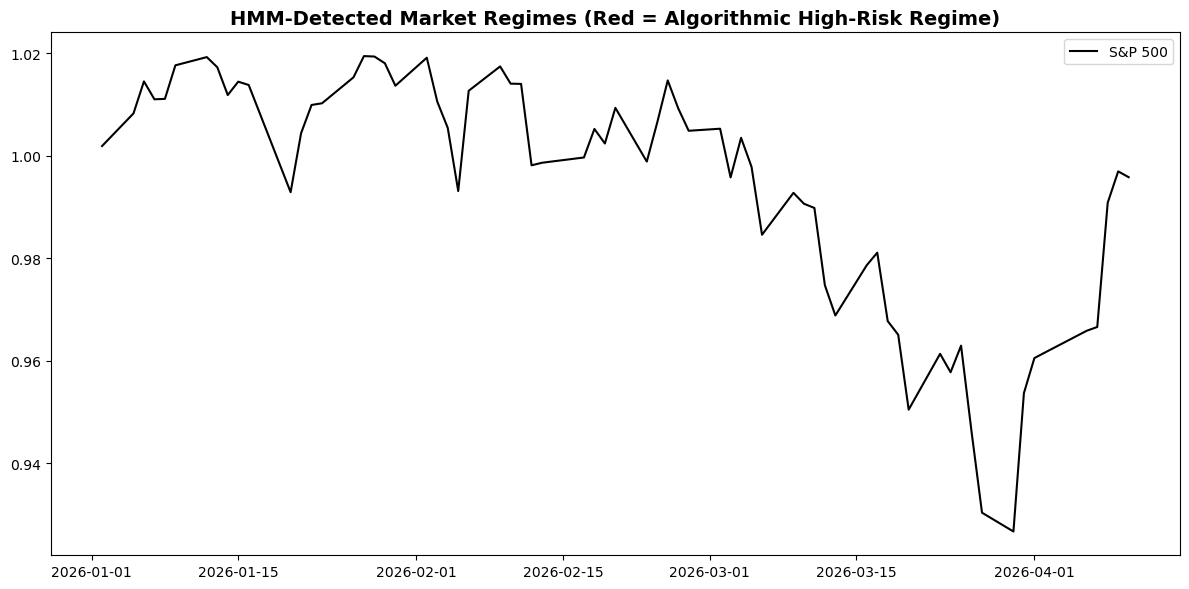

In [57]:
from hmmlearn import hmm
import numpy as np

# Use the S&P 500 daily returns to identify broad market regimes
sp500_ret = sp500.pct_change().dropna()

# HMMs need a 2D array, and we use absolute returns (volatility proxy) alongside raw returns
X = np.column_stack([sp500_ret.values, np.abs(sp500_ret.values)])

# Initialize a 2-Regime Hidden Markov Model
# We assume 2 regimes: Normal Market vs. Crisis Market
model = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
model.fit(X)

# Predict the hidden states (Regime 0 or Regime 1 for every single day)
hidden_states = model.predict(X)

# Create a clean dataframe to view the regimes over time
regime_df = pd.DataFrame({
    'S&P 500 Return': sp500_ret,
    'Regime': hidden_states
}, index=sp500_ret.index)

# Plot the S&P 500, coloring the background based on the algorithmic regime
plt.figure(figsize=(12, 6))
plt.plot(sp500_ret.index, (1 + sp500_ret).cumprod(), color='black', label='S&P 500 Indexed')

# Shade the background based on the HMM prediction
for i in range(len(regime_df) - 1):
    if regime_df['Regime'].iloc[i] == 1:
        plt.axvspan(regime_df.index[i], regime_df.index[i+1], color='red', alpha=0.2, lw=0)

plt.title('HMM-Detected Market Regimes (Red = Algorithmic High-Risk Regime)', fontsize=14, fontweight='bold')
plt.legend(['S&P 500', 'High Volatility Regime'])
plt.tight_layout()
plt.show()

In [58]:
from sklearn.decomposition import PCA
import numpy as np

def calculate_pca_variance(returns_df):
    # Standardize the data (mean=0, variance=1) before running PCA
    returns_standardized = (returns_df - returns_df.mean()) / returns_df.std()
    
    pca = PCA()
    pca.fit(returns_standardized.fillna(0)) # Fill NaNs to allow PCA to run
    
    # Extract the percentage of variance explained by PC1 (The "Market" Factor)
    pc1_variance = pca.explained_variance_ratio_[0]
    return pc1_variance

# Run PCA on the individual stock returns (not the sector averages) for both phases
pc1_p1 = calculate_pca_variance(df_stocks_filtered.loc['2025-12-31':'2026-02-27'])
pc1_p2 = calculate_pca_variance(df_stocks_filtered.loc['2026-02-27':'2026-04-10'])

print("--- PCA: EXPLANATORY POWER OF THE MARKET FACTOR (PC1) ---")
print(f"Phase 1 (Pre-Shock): PC1 explains {pc1_p1:.2%} of total stock variance.")
print(f"Phase 2 (Post-Shock): PC1 explains {pc1_p2:.2%} of total stock variance.")

--- PCA: EXPLANATORY POWER OF THE MARKET FACTOR (PC1) ---
Phase 1 (Pre-Shock): PC1 explains 62.17% of total stock variance.
Phase 2 (Post-Shock): PC1 explains 46.07% of total stock variance.


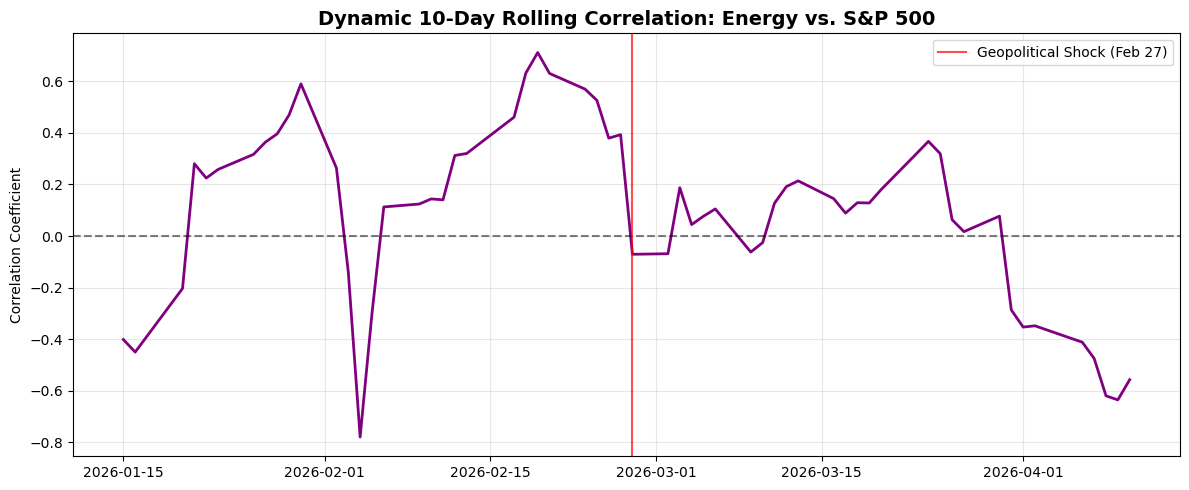

In [59]:
# Calculate a 10-day rolling correlation between the Energy sector and the S&P 500
rolling_window = 10

# Align the series
energy_returns = sector_daily['Energy'] # Assuming 'Energy' is a valid column
benchmark_returns = sp500_returns

# Calculate rolling correlation
dynamic_corr = energy_returns.rolling(window=rolling_window).corr(benchmark_returns)

plt.figure(figsize=(12, 5))
plt.plot(dynamic_corr.index, dynamic_corr, color='purple', linewidth=2)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# Highlight the February 27th Regime Shift
plt.axvline(pd.to_datetime('2026-02-27'), color='red', linestyle='-', alpha=0.7, label='Geopolitical Shock (Feb 27)')

plt.title('Dynamic 10-Day Rolling Correlation: Energy vs. S&P 500', fontsize=14, fontweight='bold')
plt.ylabel('Correlation Coefficient')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
import yfinance as yf
from statsmodels.tsa.stattools import coint

# 1. Download 2 years of history for a classic pair
print("Downloading 2-year history for Stat Arb Cointegration test...")
pair_data = yf.download(['CVX', 'XOM'], start="2024-01-01", end="2026-04-10")['Close']

# Split into historical training data and our 2026 "Shock" data
history_cvx = pair_data['CVX'].loc['2024-01-01':'2025-12-31'].dropna()
history_xom = pair_data['XOM'].loc['2024-01-01':'2025-12-31'].dropna()

shock_cvx = pair_data['CVX'].loc['2026-01-01':'2026-04-10'].dropna()
shock_xom = pair_data['XOM'].loc['2026-01-01':'2026-04-10'].dropna()

# 2. Run the Engle-Granger Cointegration Test
# The null hypothesis is NO cointegration. A p-value < 0.05 rejects the null.
score, p_value_hist, _ = coint(history_cvx, history_xom)
score, p_value_shock, _ = coint(shock_cvx, shock_xom)

print("\n--- COINTEGRATION (STATISTICAL ARBITRAGE) TEST ---")
print("Pair Tested: CVX (Chevron) vs XOM (ExxonMobil)")
print(f"Historical P-Value (2024-2025): {p_value_hist:.4f}")

if p_value_hist < 0.05:
    print("-> Result: The pair WAS historically cointegrated. A valid Stat Arb pair.")
else:
    print("-> Result: The pair was NOT historically cointegrated.")

print(f"\nQ1 2026 Shock P-Value: {p_value_shock:.4f}")

if p_value_shock < 0.05:
    print("-> Result: The pair REMAINS cointegrated. The structural relationship survived the shock.")
else:
    print("-> Result: The pair BROKE cointegration. The Q1 volatility shattered the equilibrium.")

[                       0%                       ]

[*********************100%***********************]  2 of 2 completed


--- COINTEGRATION (STATISTICAL ARBITRAGE) TEST ---
Pair Tested: CVX (Chevron) vs XOM (ExxonMobil)
Historical P-Value (2024-2025): 0.1621
-> Result: The pair was NOT historically cointegrated.

Q1 2026 Shock P-Value: 0.3608
-> Result: The pair BROKE cointegration. The Q1 volatility shattered the equilibrium.
